In [35]:
import keras

In [36]:
import ssl
import urllib.request

# Work around local CA certificate issues when keras downloads CIFAR-10.
ssl_context = ssl._create_unverified_context()
ssl._create_default_https_context = ssl._create_unverified_context
urllib.request.install_opener(
    urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
 )

import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

np.savez("cifar10_train.npz", x_train=x_train, y_train=y_train)
np.savez("cifar10_test.npz", x_test=x_test, y_test=y_test)

In [37]:
# Train shape: (Amount of pictures, size height, size width, colour channells)
# Test shape: (Amount of pictures, label)
print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [38]:
# Normalise images, because the RBG-image values are between 0 and 255, this will normalise them and help training the network.
x_train = x_train / 255
x_test = x_test / 255

[9]
[9]


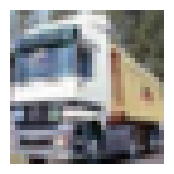

In [39]:
print(y_train[1])

import matplotlib.pyplot as plt
print(y_train[1])

plt.figure(figsize=(2,2))
plt.imshow(x_train[1])
plt.axis('off')
plt.show()

In [40]:
# Keep labels numeric for training, and map them only when you want to display the class name.
convert = {0: "airplane",
           1:"automobile",
           2:"bird",
           3: "cat",
           4: "deer",
           5: "dog",
           6: "frog",
           7: "horse",
           8: "ship",
           9: "truck"}

inverse_convert = {name: index for index, name in convert.items()}

if isinstance(y_train[0], str):
    y_train = np.array([inverse_convert[label] for label in y_train], dtype="int64")
    y_test = np.array([inverse_convert[label] for label in y_test], dtype="int64")
else:
    y_train = np.array([label[0] for label in y_train], dtype="int64")
    y_test = np.array([label[0] for label in y_test], dtype="int64")

In [41]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [42]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=(32, 32, 3), padding="same"))
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu"))
model.add(keras.layers.MaxPool2D(pool_size=(2, 2)))

# add dropout 1:
model.add(keras.layers.Dropout(rate=0.25))

# add repeated layers
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same"))
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu"))
model.add(keras.layers.MaxPool2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(rate=0.25))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(512, activation="relu"))

# add dropout 2:
model.add(keras.layers.Dropout(rate=0.50))

model.add(keras.layers.Dense(10, activation="softmax"))


optimizer = keras.optimizers.RMSprop(learning_rate=0.0001, weight_decay=1e-6)
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [43]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, verbose=1, validation_data=(x_test, y_test), shuffle=True)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3022 - loss: 1.8984 - val_accuracy: 0.4152 - val_loss: 1.6138
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4095 - loss: 1.6068 - val_accuracy: 0.4719 - val_loss: 1.4628
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.4683 - loss: 1.4682 - val_accuracy: 0.4964 - val_loss: 1.3923
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.5128 - loss: 1.3617 - val_accuracy: 0.5495 - val_loss: 1.2744
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.5420 - loss: 1.2871 - val_accuracy: 0.5636 - val_loss: 1.2277
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5623 - loss: 1.2343 - val_accuracy: 0.5882 - val_loss: 1.1503
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5799 - loss: 1.1843 - val_accuracy: 0.6020 - val_loss: 1.1263
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.5962 -

---
## Question 1

Overfitting is a phenomena where the model is too complex for the data it is trying to represent. Instead of capturing the pattern in the data, the model is so sophisticated that it starts to model the noise in the data as well, called overfitting. In such cases, the model has captured the training data almost perfectly, while not generalizing well to other data. This is observed by a training error that keeps decreasing while the error for unseen cases doesn't follow. Exact figures are difficult but is best detected as a growing gap between the training and validattion curves.

The following citation explains dropout very well: "Overfitting can be reduced by using “dropout” to prevent complex co-adaptations on the training data. On each presentation of each training case, each hidden unit is randomly omitted from the network with a probability of 0.5, so a hidden unit cannot rely on other hidden units
being present." [2] That is, dropout randomly sets some proportion of unit outputs to zero during training, with a new random mask each training iteration [1]. Then at test time the 'mean' network is used with all outgoing weights weighted by the proportion of times they were inactive (0.5 from the citation from before).

Neurons in the network now cannot rely on other units in the network so they must all be optimised on their own, greatly benefitting the model. It also causes the network to act similarly to many smaller networks that are combined, reducing complexity of the model thus also reducing overfitting.

#### References
- [1] Keras `Dropout` layer docs: https://keras.io/api/layers/regularization_layers/dropout/
- [2] Hinton, G. E., Srivastava, N., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. R. (2012).
Improving neural networks by preventing co-adaptation of feature detectors. https://arxiv.org/pdf/1207.0580


#### AI usage
I used ChatGPT to find the papers introducing Dropout since I only found docs from Keras (useful) or blog posts (not so useful) via Google. I was already familiar with Dropout so I used the paper to fact-check my own understanding of the concept.

---

## Question 2:


Plot is included below

---

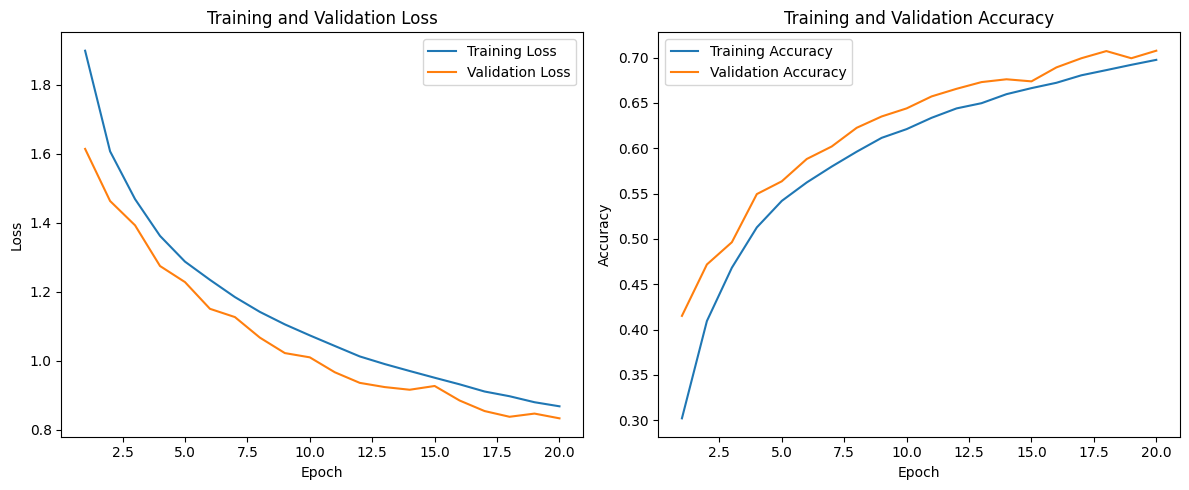

In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

---
## Question 3:

The logs show the following: The model from the learning based assignment (model1) took about 14s/epoch (375 steps $\times$ ~37-38ms). The model above (model2) took about 18s/epoch (1563 steps $\times$ ~11-12 ms/step). So model2 is $\frac{18}{14} \approx$ $1.3\times$ slower per epoch. 

Over full training, that is 360s for 20 epochs for model2 vs 84s for 6 epochs for model1. Total training thus slowed by $\frac{360}{84} \approx$ $4.3\times$.



## Question 4:
1. As shown in the computations, the epochs of the former model consisted of 375 steps and the latter model 1563 steps to complete one epoch. That said, the second model takes batches of size 32 while the first one took batches of 128. This means 

2. Combined with the fact that the learning-based model trained for 6 epochs, and this new model for 20 epochs means the total training time increases from 24 seconds to 396 seconds i.e. 16.5x slower

---